# Test Landmarks

In [1]:
import tensorflow as tf
import tensorflow_io as tfio

import os
from pathlib import Path
import time
import datetime
import numpy as np
import cv2

from matplotlib import pyplot as plt
from IPython.display import display, clear_output, update_display
from tqdm.notebook import tqdm

from joblib import Memory
from joblib import Parallel, delayed

from itertools import combinations

import torch
import facer
from spiga.inference.config import ModelConfig
from spiga.inference.framework import SPIGAFramework

2023-05-04 13:42:14.126129: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-05-04 13:42:14.179758: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-05-04 13:42:15.121244: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
TESTING_COHERENCE_LOSS = "l1"
TESTING_MAIN_LOSS = "l1"

# Dimensions
BATCH_SIZE = 20
IMG_WIDTH = 64
IMG_HEIGHT = 64
N_CHANNELS = 3


STEPS = 100000

LAMBDA1 = 1000
LAMBDA2 = 200

VIDEOS_FOLDER = 'mugoriginal'

In [3]:
# Normalizing the images to [-1, 1]
def normalize(sequence):
  return (sequence / 127.5) - 1

# Undo normalizing the images to [0, 255]
@tf.function
def normalized_sequence_to_images(sequence):
  return tf.cast((sequence + 1) * 127.5, tf.uint8)

In [4]:
def plot_sample_sequence(sample_sequence):
    plot_sequence = list(sample_sequence)
    n_frames = len(plot_sequence)
    if n_frames > 20:
        plot_sequence = plot_sequence[:20]
        n_frames = 20
    rows = ((n_frames-1) // 10)+1
    cols = max(n_frames % 10, 10)
    fig = plt.figure(figsize=(20, 4))
    for i, im in enumerate(plot_sequence):
        ax = fig.add_subplot(rows,cols,i+1)
        ax.imshow(im) 
        ax.axis('off')
    plt.show()
    plt.close()

def plot_frame(frame, title=None):
    plt.imshow(frame)
    if title is not None:
        plt.title(title)
    plt.axis('off')
    plt.show()
    plt.close()

def plot_normalized_frame(frame, title=None):
    plot_frame(normalized_sequence_to_images(frame), title)

def sequence_generator(sample_sequence):
    for i in range(sample_sequence.shape[0]):
        yield sample_sequence[i, ...]

def plot_sequence(sample_sequence):
    plot_sample_sequence(sequence_generator(sample_sequence))

def plot_normalized_sequence(sample_sequence):
    plot_sequence(normalized_sequence_to_images(sample_sequence))

def inverse_sequence_generator(sample_sequence):
    for i in range(sample_sequence.shape[-1]):
        yield sample_sequence[..., i]

def plot_inverse_sequence(sample_sequence):
    plot_sample_sequence(inverse_sequence_generator(sample_sequence))

def plot_normalized_inverse_sequence(sample_sequence):
    plot_inverse_sequence(normalized_sequence_to_images(sample_sequence))

def plot_normalized_sequence(sample_sequence):
    plot_sequence(normalized_sequence_to_images(sample_sequence))

def plot_sequence_from_tensor(sample_sequence):
    if len(sample_sequence.shape) == 5 and sample_sequence.shape[0] == 1:
        plot_sequence(sample_sequence[0])
    else:
        raise ValueError("The tensor must be of shape (1, frames, height, width, channels)")

def plot_sequence_from_normalized_tensor(sample_sequence):
    plot_sequence_from_tensor(normalized_sequence_to_images(sample_sequence))

In [5]:
videos_path = list(Path(f'../data/{VIDEOS_FOLDER}/').glob('**/*.npy'))

In [6]:
DATASET_SIZE = len(videos_path)
train_size = int(0.7 * DATASET_SIZE)
# val_size = int(0.15 * DATASET_SIZE)
test_size = int(0.3 * DATASET_SIZE)

# generate training, validation and test sets
train_paths = videos_path[:train_size]
# val_sequences = sequences[train_size:train_size+val_size]
# test_sequences = sequences[train_size+val_size:]
test_paths = videos_path[train_size:]

print(len(train_paths))
print(len(test_paths))

723
310


In [7]:
class FrameDataGenerator():
    
    def __init__(self, videos_path, batch_size=1):
        self.videos_path = videos_path
        self.n = len(videos_path)
        self._restart()
        self.batch_size = batch_size
    
    def _load_current_video(self):
        self.current_video = np.load(self.videos_path[self.current_video_index])
        # print(f"Loading video {self.current_video_index+1} of {self.n} with {self.current_video.shape[0]} frames")
    
    def __iter__(self):
        return self
    
    def _load_next_video(self):
        self.current_frame_index = 1
        self.current_video_index += 1
        self._load_current_video()
    
    def _restart(self):
        self.current_video_index = 0
        self.current_frame_index = 0
        self._load_current_video()
    

    def _current_frame(self):
        return self.current_video[self.current_frame_index]
    
    def _next_frame(self):
        return self.current_video[self.current_frame_index+1]
    
    def _previous_frame(self):
        return self.current_video[self.current_frame_index-1]
    
    def _current_video_has_next_frame(self):
        return self.current_frame_index+1 < self.current_video.shape[0]
    
    def _has_current_video(self):
        return self.current_video_index < self.n
    
    def _has_next_video(self):
        return self.current_video_index+1 < self.n
    
    def _end_of_videos(self):
            raise StopIteration
    
    def _get_current_frames(self):
        return self._previous_frame(), self._current_frame(), self._next_frame()
    
    def _get_batch(self):
        batch_previous_frame = []
        batch_current_frame = []
        batch_next_frame = []
        for i in range(self.batch_size):
            previous_frame, current_frame, next_frame = self._get_current_frames()
            batch_previous_frame.append(previous_frame)
            batch_current_frame.append(current_frame)
            batch_next_frame.append(next_frame)
        return np.array(batch_previous_frame), np.array(batch_current_frame), np.array(batch_next_frame)


    def __next__(self):
        self.current_frame_index += 1 # Frame index start at one because we have to return the previous frame
        if not self._has_current_video():
            self._end_of_videos()
        while not self._current_video_has_next_frame():
            if self._has_next_video():
                self._load_next_video()
            else:
                self._end_of_videos()
        return self._get_batch()
    
    def __call__(self):
        return next(self)
    
    def take(self, n):
        for i in range(n):
            try:
                yield self()
            except StopIteration:
                self._restart()
    
    def __iter__(self):
        return self
    
    def repeat(self):
        while True:
            try:
                yield self()
            except StopIteration:
                self._restart()

In [8]:
train_generator = FrameDataGenerator(train_paths, batch_size=20)
test_generator = FrameDataGenerator(test_paths, batch_size=20)

previous_frame, current_frame, next_frame = next(test_generator)
print(previous_frame.shape)
print(current_frame.shape)
print(next_frame.shape)

(20, 448, 448, 3)
(20, 448, 448, 3)
(20, 448, 448, 3)


In [9]:
BASE_PATH = Path('/home/jupyter/')
DATA_PATH = BASE_PATH / 'data'

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [12]:
face_detector = facer.face_detector('retinaface/mobilenet', device=device)
# Process image
dataset = 'wflw'
processor = SPIGAFramework(ModelConfig(dataset))

SPIGA model loaded!


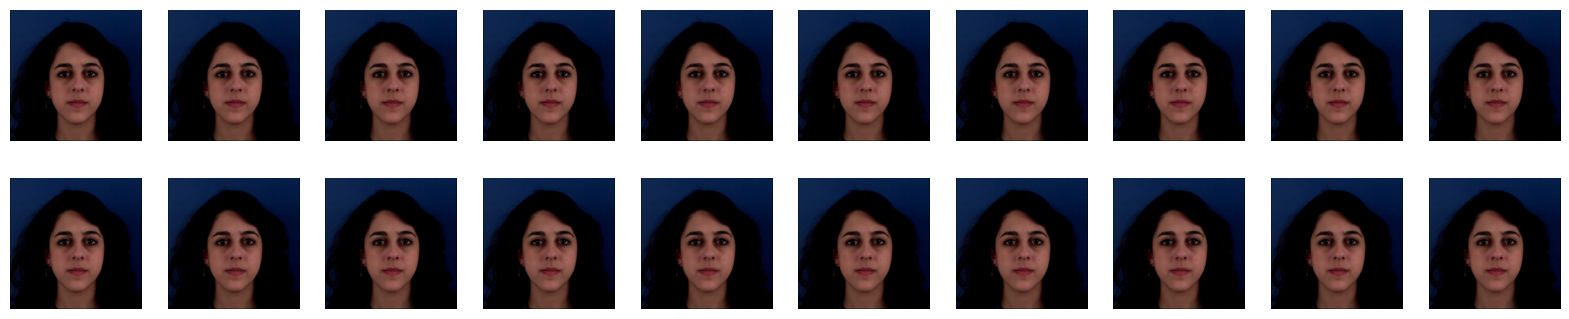

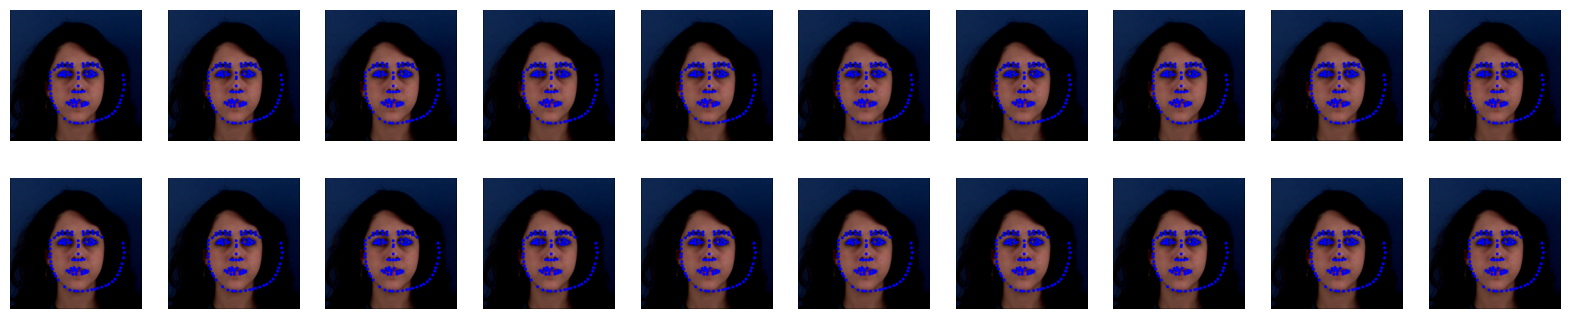

In [15]:
out_frames = []
out_landmarks = []
out_bbox_frames = []

for image in current_frame:
    
    image =  normalized_sequence_to_images(image)
    image = np.array(image, dtype=np.uint8)

    image = torch.from_numpy(image)
    faces = face_detector(facer.hwc2bchw(image).to(device=device))
                
    if len(faces) > 0:
      bbox = faces['rects'].detach().cpu().numpy()
      image = image.detach().cpu().numpy()
      # image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

      features = processor.inference(image, bbox)
      landmarks = np.array(features['landmarks'][0])
      out_landmarks.append(landmarks)
      
      for (x, y) in landmarks:
          cv2.circle(image, (int(x), int(y)), 5, (0, 0, 255), -1)
      out_frames.append(image)

      # for (x1, y1, x2, y2) in bbox:
      #     cv2.rectangle(image, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 1)
      # out_bbox_frames.append(image)

    else:
      print("No Face Detected")
     
    out_frames.append(image)
 
out_frames = np.array(out_frames)

plot_normalized_sequence(current_frame)
plot_sequence(out_frames)
# plot_sequence(out_bbox_frames)